<a href="https://colab.research.google.com/github/rudalshan0412-code/attention-is-all-you-need-pytorch/blob/main/12)_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Google Drive 연결

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 프로젝트 경로 설정

from pathlib import Path
import sys

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/attention_is_all_you_need"
)

SRC_DIR = PROJECT_ROOT / "src"

PROJECT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

SRC_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC_DIR:", SRC_DIR)

PROJECT_ROOT: /content/drive/MyDrive/attention_is_all_you_need
SRC_DIR: /content/drive/MyDrive/attention_is_all_you_need/src


In [ ]:
# src 파일 목록 확인

for path in sorted(SRC_DIR.glob("*.py")):
    print(path.name)

attention.py
dataset.py
decoder.py
decoder_layer.py
encoder.py
encoder_layer.py
feed_forward.py
mask.py
multi_head_attention.py
positional_encoding.py
tokenizer.py
transformer.py
vocabulary.py


In [ ]:
# 현재 transformer.py 실제 코드 확인

transformer_path = SRC_DIR / "transformer.py"

print(transformer_path.read_text())


import math

import torch.nn as nn

from src.positional_encoding import PositionalEncoding
from src.encoder import Encoder
from src.decoder import Decoder


class Transformer(nn.Module):
    def __init__(
        self,
        source_vocab_size,
        target_vocab_size,
        d_model,
        num_heads,
        d_ff,
        num_encoder_layers,
        num_decoder_layers,
        max_len,
        dropout=0.1,
    ):
        super().__init__()

        self.d_model = d_model

        self.source_embedding = nn.Embedding(
            source_vocab_size,
            d_model,
        )

        self.target_embedding = nn.Embedding(
            target_vocab_size,
            d_model,
        )

        self.source_positional_encoding = PositionalEncoding(
            d_model,
            max_len,
            dropout,
        )

        self.target_positional_encoding = PositionalEncoding(
            d_model,
            max_len,
            dropout,
        )

        self.encoder = En

In [ ]:
# 현재 mask.py 실제 코드 확인

mask_path = SRC_DIR / "mask.py"

print(mask_path.read_text())


import torch


def create_padding_mask(
    token_ids,
    pad_idx,
):
    mask = token_ids != pad_idx

    mask = mask.unsqueeze(1).unsqueeze(2)

    return mask


def create_causal_mask(
    seq_len,
    device=None,
):
    mask = torch.ones(
        seq_len,
        seq_len,
        dtype=torch.bool,
        device=device,
    )

    mask = torch.tril(mask)

    mask = mask.unsqueeze(0).unsqueeze(0)

    return mask



In [ ]:
# tokenizer.py 확인

tokenizer_path = SRC_DIR / "tokenizer.py"

print(tokenizer_path.read_text())


import re


def tokenize(text):
    text = text.lower()

    tokens = re.findall(
        r"\w+|[^\w\s]",
        text,
        flags=re.UNICODE,
    )

    return tokens



In [ ]:
# 현재 vocabulary.py 확인

vocabulary_path = SRC_DIR / "vocabulary.py"

print(vocabulary_path.read_text())


PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
BOS_TOKEN = "<BOS>"
EOS_TOKEN = "<EOS>"

PAD_IDX = 0
UNK_IDX = 1
BOS_IDX = 2
EOS_IDX = 3


class Vocabulary:
    def __init__(self, tokenized_sentences):
        self.itos = [
            PAD_TOKEN,
            UNK_TOKEN,
            BOS_TOKEN,
            EOS_TOKEN,
        ]

        self.stoi = {
            PAD_TOKEN: PAD_IDX,
            UNK_TOKEN: UNK_IDX,
            BOS_TOKEN: BOS_IDX,
            EOS_TOKEN: EOS_IDX,
        }

        for tokens in tokenized_sentences:
            for token in tokens:
                if token not in self.stoi:
                    index = len(self.itos)

                    self.stoi[token] = index
                    self.itos.append(token)

    def __len__(self):
        return len(self.itos)

    def token_to_id(self, token):
        return self.stoi.get(
            token,
            UNK_IDX,
        )

    def id_to_token(self, index):
        return self.itos[index]

    def encode(self, tokens):


In [ ]:
# 현재 dataset.py 확인

dataset_path = SRC_DIR / "dataset.py"

print(dataset_path.read_text())


import torch

from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence

from src.vocabulary import (
    BOS_TOKEN,
    EOS_TOKEN,
    PAD_IDX,
)


class TranslationDataset(Dataset):
    def __init__(
        self,
        source_sentences,
        target_sentences,
        source_tokenizer,
        target_tokenizer,
        source_vocab,
        target_vocab,
    ):
        self.source_sentences = source_sentences
        self.target_sentences = target_sentences

        self.source_tokenizer = source_tokenizer
        self.target_tokenizer = target_tokenizer

        self.source_vocab = source_vocab
        self.target_vocab = target_vocab

    def __len__(self):
        return len(
            self.source_sentences
        )

    def __getitem__(self, index):
        source_tokens = self.source_tokenizer(
            self.source_sentences[index]
        )

        target_tokens = self.target_tokenizer(
            self.target_sentences[index]
        )

    

In [ ]:
# Toy Source Sentence 준비

source_sentences = [
    "I love cats.",
    "You like dogs.",
    "We study attention.",
    "Transformers are powerful.",
    "I like apples.",
    "You love music.",
    "We study transformers.",
    "Cats are cute.",
]

In [ ]:
# Toy Target Sentence 준비

target_sentences = [
    "Cats are lovely.",
    "Dogs are friendly.",
    "We learn attention.",
    "Transformers process sequences.",
    "Apples are delicious.",
    "Music is wonderful.",
    "We learn transformers.",
    "Cats are adorable.",
]

print(len(source_sentences))
print(len(target_sentences))

8
8


In [ ]:
# Tokenize

from src.tokenizer import tokenize

tokenized_source_sentences = [
    tokenize(sentence)
    for sentence in source_sentences
]

tokenized_target_sentences = [
    tokenize(sentence)
    for sentence in target_sentences
]

print(tokenized_source_sentences[0])
print(tokenized_target_sentences[0])

['i', 'love', 'cats', '.']
['cats', 'are', 'lovely', '.']


In [ ]:
# Source Vacabulary 생성

from src.vocabulary import (
    Vocabulary,
    PAD_IDX, # 0
    UNK_IDX, # 1
    BOS_IDX, # 2
    EOS_IDX, # 3
)

source_vocab = Vocabulary(
    tokenized_source_sentences
)

print("Source vocabulary size:", len(source_vocab)) # vocabulary len
print(source_vocab.itos) # 고정 인덱스, 나온 순으로(중복의 경우 최초 케이스)

Source vocabulary size: 20
['<PAD>', '<UNK>', '<BOS>', '<EOS>', 'i', 'love', 'cats', '.', 'you', 'like', 'dogs', 'we', 'study', 'attention', 'transformers', 'are', 'powerful', 'apples', 'music', 'cute']


In [ ]:
# Target Vocabulary 생성

target_vocab = Vocabulary(
    tokenized_target_sentences
)

print("Target vocabulary size:", len(target_vocab)) # vocabulary len
print(target_vocab.itos) # 고정 인덱스, 나온 순으로(중복의 경우 최초 케이스)

# source vocabulary와 target vocabulary가 서로 다른지 확인

print(
    "Same vocabulary object:",
    source_vocab is target_vocab,
)

Target vocabulary size: 22
['<PAD>', '<UNK>', '<BOS>', '<EOS>', 'cats', 'are', 'lovely', '.', 'dogs', 'friendly', 'we', 'learn', 'attention', 'transformers', 'process', 'sequences', 'apples', 'delicious', 'music', 'is', 'wonderful', 'adorable']
Same vocabulary object: False


In [ ]:
# Special Token 확인

print("PAD_IDX:", PAD_IDX)
print("UNK_IDX:", UNK_IDX)
print("BOS_IDX:", BOS_IDX)
print("EOS_IDX:", EOS_IDX)

PAD_IDX: 0
UNK_IDX: 1
BOS_IDX: 2
EOS_IDX: 3


In [ ]:
# TranslationDataset 생성

from src.dataset import (
    TranslationDataset, # BOS, EOS 붙여서 tensor 생성
    collate_fn, # PAD 채우기
)

dataset = TranslationDataset(
    source_sentences=source_sentences,
    target_sentences=target_sentences,
    source_tokenizer=tokenize,
    target_tokenizer=tokenize,
    source_vocab=source_vocab,
    target_vocab=target_vocab,
)

print("Dataset size:", len(dataset))

Dataset size: 8


In [ ]:
# Dataset sample 확인

source_ids, target_ids = dataset[0]

print("source_ids:")
print(source_ids)

print()

print("target_ids:")
print(target_ids)

print()

print("source dtype:", source_ids.dtype) # int64 여야 인덱스를 표현할 수 있음
print("target dtype:", target_ids.dtype)

source_ids:
tensor([2, 4, 5, 6, 7, 3])

target_ids:
tensor([2, 4, 5, 6, 7, 3])

source dtype: torch.int64
target dtype: torch.int64


In [ ]:
# Token ID를 다시 decode해서 확인

print(
    "Source:",
    source_vocab.decode( # ids -> token
        source_ids.tolist()
    ),
)

print(
    "Target:",
    target_vocab.decode(
        target_ids.tolist()
    ),
)

Source: ['<BOS>', 'i', 'love', 'cats', '.', '<EOS>']
Target: ['<BOS>', 'cats', 'are', 'lovely', '.', '<EOS>']


In [ ]:
# DataLoader 생성

from torch.utils.data import DataLoader

dataloader = DataLoader(
    dataset, # (source_ids, target_ids) 형태의 tensor 하나씩 꺼내옴
    batch_size=4, # 한번에 처리할 tensor의 개수를 4개로 묶어줌
    shuffle=True, # 섞어줌으로서 편향 / 순서 암기를 막아줌
    collate_fn=collate_fn, # padding 진행
)

print(
    "Number of batches:",
    len(dataloader),
)

Number of batches: 2


In [ ]:
# 첫 Batch 꺼내기

source_batch, target_batch = next(
    iter(dataloader)
)

print("source_batch:")
print(source_batch)

print()

print("target_batch:")
print(target_batch)

source_batch:
tensor([[ 2, 14, 15, 16,  7,  3],
        [ 2,  8,  9, 10,  7,  3],
        [ 2,  4,  5,  6,  7,  3],
        [ 2,  4,  9, 17,  7,  3]])

target_batch:
tensor([[ 2, 13, 14, 15,  7,  3],
        [ 2,  8,  5,  9,  7,  3],
        [ 2,  4,  5,  6,  7,  3],
        [ 2, 16,  5, 17,  7,  3]])


In [ ]:
# source_batch Shape 확인

print(
    "source_batch shape:",
    source_batch.shape, # 이 경우에는 전부 길이가 같아 PAD를 추가하지 않았다.(만약 길이가 다른 경우, 최대 길이에 맞춰 PAD로 채워준다.)
)

print(
    "source_batch dtype:",
    source_batch.dtype,
)

source_batch shape: torch.Size([4, 6])
source_batch dtype: torch.int64


In [ ]:
# target_batch Shape 확인

print(
    "target_batch shape:",
    target_batch.shape, # 이 경우에는 전부 길이가 같아 PAD를 추가하지 않았다.(만약 길이가 다른 경우, 최대 길이에 맞춰 PAD로 채워준다.)
)

print(
    "target_batch dtype:",
    target_batch.dtype,
)

target_batch shape: torch.Size([4, 6])
target_batch dtype: torch.int64


In [ ]:
# decoder_input 생성

decoder_input = target_batch[:, :-1] # 모든 행, 마지막 요소를 제외한 모든 열(-> 3 제외)

# decoder의 경우 문장의 다음 요소를 예측하는 역할을 한다. 이때, EOS가 decoder에 들어오면 문장이 끝났을 때 다음을 예측하는 것임으로 EOS를 제외한다.

print(decoder_input)

tensor([[ 2, 13, 14, 15,  7],
        [ 2,  8,  5,  9,  7],
        [ 2,  4,  5,  6,  7],
        [ 2, 16,  5, 17,  7]])


In [ ]:
# labels 생성

labels = target_batch[:, 1:] # 모든 행, 첫번째 요소를 제외한 모든 열(-> 2 제외)

# labels의 경우 decoder가 맞춰야하는 정답이다. decoder는 BOS가 주어진 상태에서 다음을 예측하기에 labels에서 BOS를 제외한다.

print(labels)

tensor([[13, 14, 15,  7,  3],
        [ 8,  5,  9,  7,  3],
        [ 4,  5,  6,  7,  3],
        [16,  5, 17,  7,  3]])


In [ ]:
# 두 shape 확인

print(
    "target_batch:",
    target_batch.shape,
)

print(
    "decoder_input:",
    decoder_input.shape, # EOS가 제외되었기에 하나 적다.
)

print(
    "labels:",
    labels.shape, # BOS가 제외되었기에 하나 적다.
)


print(
    decoder_input.shape
    == labels.shape
)

target_batch: torch.Size([4, 6])
decoder_input: torch.Size([4, 5])
labels: torch.Size([4, 5])
True


In [ ]:
# 첫 Batch Target Shift를 숫자로 확인

print("Full target:")
print(target_batch[0])

print()

print("Decoder input:")
print(decoder_input[0])

print()

print("Labels:")
print(labels[0])

Full target:
tensor([ 2, 13, 14, 15,  7,  3])

Decoder input:
tensor([ 2, 13, 14, 15,  7])

Labels:
tensor([13, 14, 15,  7,  3])


In [ ]:
# Vocabulary로 decode 해서 직접 확인

# index -> token
full_target_tokens = target_vocab.decode(
    target_batch[0].tolist()
)

decoder_input_tokens = target_vocab.decode(
    decoder_input[0].tolist()
)

label_tokens = target_vocab.decode(
    labels[0].tolist()
)

print(
    "Full target:",
    full_target_tokens,
)

print(
    "Decoder input:",
    decoder_input_tokens,
)

print(
    "Labels:",
    label_tokens,
)

Full target: ['<BOS>', 'transformers', 'process', 'sequences', '.', '<EOS>']
Decoder input: ['<BOS>', 'transformers', 'process', 'sequences', '.']
Labels: ['transformers', 'process', 'sequences', '.', '<EOS>']


In [ ]:
# Source Padding Mask 생성

from src.mask import (
    create_padding_mask, # PAD를 전부 무시
    create_causal_mask, # 미래 정보를 모두 무시
)

source_mask = create_padding_mask(
    source_batch,
    PAD_IDX,
)

print("source_batch shape:")
print(source_batch.shape)

print()

print("source_mask shape:") # (batch, 1, 1, key_len)
print(source_mask.shape)

source_batch shape:
torch.Size([4, 6])

source_mask shape:
torch.Size([4, 1, 1, 6])


In [ ]:
# Target Padding Mask 생성

target_padding_mask = create_padding_mask(
    decoder_input,
    PAD_IDX,
)

print("decoder_input shape:")
print(decoder_input.shape)

print()

print("target_padding_mask shape:") # (batch, 1, 1, key_len)
print(target_padding_mask.shape)

decoder_input shape:
torch.Size([4, 5])

target_padding_mask shape:
torch.Size([4, 1, 1, 5])


In [ ]:
# Casual Mask 생성

causal_mask = create_causal_mask(
    decoder_input.size(1),
    device=decoder_input.device,
)

print("decoder_input length:")
print(decoder_input.size(1))

print()

print("causal_mask shape:") # shape = (1, 1, seq_len, seq_len)
print(causal_mask.shape)

print()

print("causal_mask:") # 하삼각행렬
print(causal_mask)

decoder_input length:
5

causal_mask shape:
torch.Size([1, 1, 5, 5])

causal_mask:
tensor([[[[ True, False, False, False, False],
          [ True,  True, False, False, False],
          [ True,  True,  True, False, False],
          [ True,  True,  True,  True, False],
          [ True,  True,  True,  True,  True]]]])


In [ ]:
# Target Mask 결합

target_mask = ( # 둘 중 하나라도 0이면 0
    target_padding_mask
    & causal_mask
)

print("target_padding_mask:")
print(target_padding_mask.shape)

print()

print("causal_mask:")
print(causal_mask.shape)

print()

print("target_mask:")
print(target_mask.shape)

target_padding_mask:
torch.Size([4, 1, 1, 5])

causal_mask:
torch.Size([1, 1, 5, 5])

target_mask:
torch.Size([4, 1, 5, 5])


In [ ]:
# Mask shape 한번에 검증

print(
    "source_batch:",
    source_batch.shape,
)

print(
    "target_batch:",
    target_batch.shape,
)

print(
    "decoder_input:",
    decoder_input.shape,
)

print(
    "labels:",
    labels.shape,
)

print(
    "source_mask:",
    source_mask.shape,
)

print(
    "target_padding_mask:",
    target_padding_mask.shape,
)

print(
    "causal_mask:",
    causal_mask.shape,
)

print(
    "target_mask:",
    target_mask.shape,
)

source_batch: torch.Size([4, 6])
target_batch: torch.Size([4, 6])
decoder_input: torch.Size([4, 5])
labels: torch.Size([4, 5])
source_mask: torch.Size([4, 1, 1, 6])
target_padding_mask: torch.Size([4, 1, 1, 5])
causal_mask: torch.Size([1, 1, 5, 5])
target_mask: torch.Size([4, 1, 5, 5])


In [ ]:
# Transformer 생성

from src.transformer import Transformer

transformer = Transformer(
    source_vocab_size=len(source_vocab),
    target_vocab_size=len(target_vocab),
    d_model=32,
    num_heads=4,
    d_ff=64,
    num_encoder_layers=2,
    num_decoder_layers=2,
    max_len=50,
    dropout=0.1,
)

print(transformer)

Transformer(
  (source_embedding): Embedding(20, 32)
  (target_embedding): Embedding(22, 32)
  (source_positional_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (target_positional_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): Encoder(
    (layers): ModuleList(
      (0-1): 2 x EncoderLayer(
        (self_attention): MultiHeadAttention(
          (W_Q): Linear(in_features=32, out_features=32, bias=True)
          (W_K): Linear(in_features=32, out_features=32, bias=True)
          (W_V): Linear(in_features=32, out_features=32, bias=True)
          (attention): ScaledDotProductAttention()
          (W_O): Linear(in_features=32, out_features=32, bias=True)
        )
        (feed_forward): PositionwiseFeedForward(
          (linear1): Linear(in_features=32, out_features=64, bias=True)
          (linear2): Linear(in_features=64, out_features=32, bias=True)
        )
        (dropout1): Dropout(p=0.1, inplace=F

In [ ]:
# Device 설정

import torch

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: cuda


In [ ]:
# Transformer를 Device로 이동

transformer = transformer.to(device)

In [ ]:
# 첫 Batch도 Device로 이동

source_batch = source_batch.to(device)
target_batch = target_batch.to(device)

decoder_input = target_batch[:, :-1]
labels = target_batch[:, 1:]

In [ ]:
# Mask도 다시 생성

source_mask = create_padding_mask(
    source_batch,
    PAD_IDX,
)

target_padding_mask = create_padding_mask(
    decoder_input,
    PAD_IDX,
)

causal_mask = create_causal_mask(
    decoder_input.size(1),
    device=decoder_input.device,
)

target_mask = (
    target_padding_mask
    & causal_mask
)

In [ ]:
# Device 확인

print(
    "Model device:",
    next(transformer.parameters()).device,
)

print(
    "source_batch device:",
    source_batch.device,
)

print(
    "decoder_input device:",
    decoder_input.device,
)

print(
    "source_mask device:",
    source_mask.device,
)

print(
    "target_mask device:",
    target_mask.device,
)

Model device: cuda:0
source_batch device: cuda:0
decoder_input device: cuda:0
source_mask device: cuda:0
target_mask device: cuda:0


In [ ]:
# 첫 Transformer Forward

transformer.train()

logits, _, _, _ = transformer(
    source_batch, # shape = (B, S_src) / 원본 입력 문장이 패딩 처리됨
    decoder_input, # shape = (B, S_tgt) / decoder 에 입력되는 패딩 처리됨 target
    source_mask, # padding mask
    target_mask, # padding mask + casual mask
)

print("logits shape:")
print(logits.shape) # shape = (B, S_tgt, V_tgt) / decoder에서 나온 결과를 펼쳐서 측정된 각 value 별 점수

logits shape:
torch.Size([4, 5, 22])


In [ ]:
# Logits Shape 확인

print(
    "decoder_input shape:",
    decoder_input.shape,
)

print(
    "logits shape:",
    logits.shape,
)

print(
    "target vocabulary size:",
    len(target_vocab),
)

print(
    logits.shape[0]
    == decoder_input.shape[0]
)

print(
    logits.shape[1]
    == decoder_input.shape[1]
)

print(
    logits.shape[2]
    == len(target_vocab)
)

decoder_input shape: torch.Size([4, 5])
logits shape: torch.Size([4, 5, 22])
target vocabulary size: 22
True
True
True


In [ ]:
# Logits 마지막 차원 확인

assert (
    logits.size(-1)
    == len(target_vocab)
)

print(
    "Logits vocabulary dimension OK"
)

Logits vocabulary dimension OK


In [ ]:
# ignore_index = PAD_IDX

import torch.nn as nn

criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_IDX # PAD IDX는 고정 인덱스 0
)

ignore_index = PAD_IDX

In [ ]:
# logits reshape

flattened_logits = logits.reshape( # -1의 뜻: logits.size(-1) / 여기선 V_tgt 을 제외하고는 차원들을 하나로 합침
    -1,
    logits.size(-1),
)

print(
    "Original logits:",
    logits.shape,
)

print(
    "Flattened logits:", # B와 S_tgt를 합침 -> B*S_tgt
    flattened_logits.shape, # labels의 shape가 (B, S_tgt)이다. 이를 하나로 펴주면 정답 번호의 개수가 맞는다.
)

NameError: name 'logits' is not defined

In [ ]:
# labels reshape

flattened_labels = labels.reshape(-1)

print(
    "Original labels:",
    labels.shape,
)

print(
    "Flattened labels:", # 정답 번호의 개수를 logits와 1:1로 맞춰준다.
    flattened_labels.shape,
)

Original labels: torch.Size([4, 5])
Flattened labels: torch.Size([20])


In [ ]:
# loss 한번에 계산

loss = criterion( # softmaㅌ 확률 변환 -> cross entropy 손실 계산 -> PAD 토큰 제외 순으로 계산
    flattened_logits,
    flattened_labels,
)

print("Loss:") # 예측한 점수표와 실제 정답 번호를 비교하여 전체 loss의 평균값을 scalar로 계산
print(loss)

Loss:
tensor(3.3387, device='cuda:0', grad_fn=<NllLossBackward0>)


In [ ]:
# loss가 Scalar인지 확인

print("loss shape:")
print(loss.shape)

print()

print("loss ndim:")
print(loss.ndim)

assert loss.ndim == 0

print("Scalar loss OK")

loss shape:
torch.Size([])

loss ndim:
0
Scalar loss OK


In [ ]:
# Adam Optimizer 생성

'''
Adaptive Moment Estination(ADAM) : 경사 하강법과는 다르게 관성(이전 스텝의 방향 유지),
보폭 적응(자주 변하는 가중치는 보폭을 줄이고, 드물게 변하는 가중치는 보폭을 늘려 모든 파라미터가 골고루 학습되게 함)
'''
optimizer = torch.optim.Adam(
    transformer.parameters(), # 가중치 목록 전부 넘겨서 자동 계산
    lr=1e-3, # learning rate
)

print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [ ]:
# Parameter이 실제로 바뀌는지 확인

parameter = next( # next() / 다음 값을 꺼내오는 함수 -> 모든 가중치가 들어있는 transformer.parameters()에서 첫번째 파라미터를 꺼냄
    transformer.parameters()
)

before = parameter.detach().clone() # 현재 모든 parameter을 복사해서 따로 메모리에 저장

print("Parameter shape:")
print(parameter.shape)

Parameter shape:
torch.Size([20, 32])


In [ ]:
# Gradient(기울기) 초기화

'''
경사하강법: weight에 대한 loss의 변화량 을 줄이는 방향으로 진행됨.
 Pytorch에서의 loss.backwrd는 이전 기울기에 다음 기울기를 더하는 방법으로 기울기가 누적됨.
 즉, 이번 batch에서의 순수한 기울기 보기 위해서 기록을 0으로 초기화 시켜줄 필요가 있음
'''

optimizer.zero_grad()

print(parameter.grad)

None


In [ ]:
# loss.backward() 실행

loss.backward()

In [ ]:
# Gradient 생성 확인

print(
    "Gradient is None:",
    parameter.grad is None,
)

if parameter.grad is not None:
    print(
        "Gradient shape:",
        parameter.grad.shape,
    )

Gradient is None: False
Gradient shape: torch.Size([20, 32])


In [ ]:
# Gradient가 실제 값을 가지는지 확인

if parameter.grad is not None:
    print(
        "Gradient absolute mean:",
        parameter.grad.abs().mean().item(), # gradient의 절댓값 평균을 float로 꺼냄(중간 확인 or 기울기 소실/폭발 일어나는지 확인)
    )

Gradient absolute mean: 0.0010742500890046358


In [ ]:
# optimizer.step() 실행

optimizer.step() # 실제 가중치 변경

In [ ]:
# parametet가 실제로 바뀌었는지 확인

after = parameter.detach().clone()

print(
    "Exactly equal:", # 완전히 일치하는지
    torch.equal(
        before,
        after,
    ),
)

print(
    "All close:",
    torch.allclose( # 허용 오차 범위 내에서 거의 같은지
        before,
        after,
    ),
)

Exactly equal: False
All close: False


In [ ]:
# Training용 transformer 새로 생성

torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# 모델 생성

transformer = Transformer(
    source_vocab_size=len(source_vocab),
    target_vocab_size=len(target_vocab),
    d_model=32,
    num_heads=4,
    d_ff=64,
    num_encoder_layers=2,
    num_decoder_layers=2,
    max_len=50,
    dropout=0.1,
)

transformer = transformer.to(device)

In [ ]:
# Criterion과 Optimizer 다시 생성

criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_IDX
)

optimizer = torch.optim.Adam(
    transformer.parameters(),
    lr=1e-3,
)

In [ ]:
# 전체 Training Loop 작성

num_epochs = 100

loss_history = []

for epoch in range(num_epochs):

    transformer.train()

    total_loss = 0.0

    for source_batch, target_batch in dataloader:

        source_batch = source_batch.to(device)
        target_batch = target_batch.to(device)

        decoder_input = target_batch[:, :-1]
        labels = target_batch[:, 1:]

        source_mask = create_padding_mask(
            source_batch,
            PAD_IDX,
        )

        target_padding_mask = create_padding_mask(
            decoder_input,
            PAD_IDX,
        )

        causal_mask = create_causal_mask(
            decoder_input.size(1),
            device=decoder_input.device,
        )

        target_mask = (
            target_padding_mask
            & causal_mask
        )

        optimizer.zero_grad()

        logits, _, _, _ = transformer(
            source_batch,
            decoder_input,
            source_mask,
            target_mask,
        )

        loss = criterion(
            logits.reshape(
                -1,
                logits.size(-1),
            ),
            labels.reshape(-1),
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    average_loss = (
        total_loss
        / len(dataloader)
    )

    loss_history.append(
        average_loss
    )

    if (
        epoch == 0
        or (epoch + 1) % 10 == 0
    ):
        print(
            f"Epoch {epoch + 1:3d} "
            f"| Loss: {average_loss:.4f}"
        )

Epoch   1 | Loss: 3.1384
Epoch  10 | Loss: 2.0560
Epoch  20 | Loss: 1.3809
Epoch  30 | Loss: 0.9454
Epoch  40 | Loss: 0.6367
Epoch  50 | Loss: 0.4574
Epoch  60 | Loss: 0.3436
Epoch  70 | Loss: 0.2270
Epoch  80 | Loss: 0.1658
Epoch  90 | Loss: 0.1456
Epoch 100 | Loss: 0.1046


In [ ]:
# 시작 loss와 마지막 loss 비교

print(
    "First epoch loss:",
    loss_history[0],
)

print(
    "Last epoch loss:",
    loss_history[-1],
)

print(
    "Loss decreased:",
    loss_history[-1]
    < loss_history[0],
)

First epoch loss: 3.1384247541427612
Last epoch loss: 0.10462351515889168
Loss decreased: True


In [ ]:
# Loss History 확인

print(
    "Number of recorded epochs:",
    len(loss_history),
)

Number of recorded epochs: 100


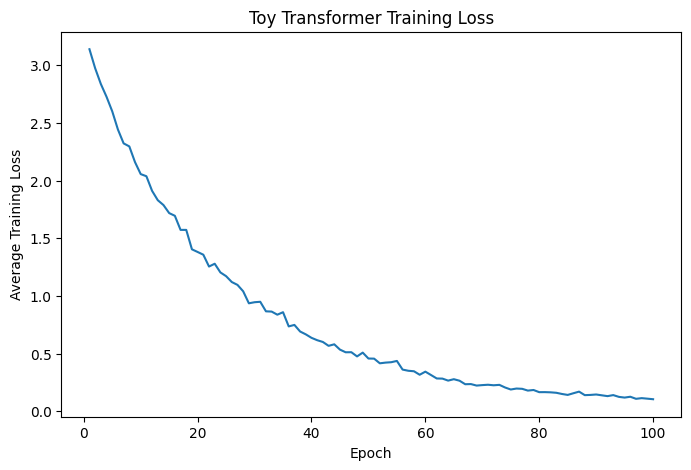

In [ ]:
# Loss Graph

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(
        1,
        num_epochs + 1,
    ),
    loss_history,
)

plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.title("Toy Transformer Training Loss")

plt.show()

In [ ]:
# 최종 통합 테스트 준비

# 작은 batch 가져와 확인

source_batch, target_batch = next(
    iter(dataloader)
)

source_batch = source_batch.to(device)
target_batch = target_batch.to(device)

decoder_input = target_batch[:, :-1]
labels = target_batch[:, 1:]

source_mask = create_padding_mask(
    source_batch,
    PAD_IDX,
)

target_padding_mask = create_padding_mask(
    decoder_input,
    PAD_IDX,
)

causal_mask = create_causal_mask(
    decoder_input.size(1),
    device=decoder_input.device,
)

target_mask = (
    target_padding_mask
    & causal_mask
)

transformer.train()

optimizer.zero_grad()

logits, _, _, _ = transformer(
    source_batch,
    decoder_input,
    source_mask,
    target_mask,
)

loss = criterion(
    logits.reshape(
        -1,
        logits.size(-1),
    ),
    labels.reshape(-1),
)

loss.backward()

In [ ]:
# 최종 조건 검사

print(
    "1. PAD_IDX == 0:",
    PAD_IDX == 0,
)

print(
    "2. UNK_IDX == 1:",
    UNK_IDX == 1,
)

print(
    "3. BOS_IDX == 2:",
    BOS_IDX == 2,
)

print(
    "4. EOS_IDX == 3:",
    EOS_IDX == 3,
)

print(
    "5. Separate vocabularies:",
    source_vocab is not target_vocab,
)

print(
    "6. Dataset size:",
    len(dataset),
)

print(
    "7. source dtype:",
    source_batch.dtype,
)

print(
    "8. target dtype:",
    target_batch.dtype,
)

print(
    "9. Decoder length correct:",
    decoder_input.shape[1]
    == target_batch.shape[1] - 1,
)

print(
    "10. Label shape correct:",
    labels.shape
    == decoder_input.shape,
)

print(
    "11. Decoder starts with BOS:",
    torch.all(
        decoder_input[:, 0]
        == BOS_IDX
    ).item(),
)

print(
    "12. source_mask shape:",
    source_mask.shape,
)

print(
    "13. target_mask shape:",
    target_mask.shape,
)

print(
    "14. logits shape:",
    logits.shape,
)

print(
    "15. Logits shape correct:",
    logits.shape
    == (
        source_batch.size(0),
        decoder_input.size(1),
        len(target_vocab),
    ),
)

print(
    "16. Loss is scalar:",
    loss.ndim == 0,
)

print(
    "17. Loss is finite:",
    torch.isfinite(loss).item(),
)

1. PAD_IDX == 0: True
2. UNK_IDX == 1: True
3. BOS_IDX == 2: True
4. EOS_IDX == 3: True
5. Separate vocabularies: True
6. Dataset size: 8
7. source dtype: torch.int64
8. target dtype: torch.int64
9. Decoder length correct: True
10. Label shape correct: True
11. Decoder starts with BOS: True
12. source_mask shape: torch.Size([4, 1, 1, 6])
13. target_mask shape: torch.Size([4, 1, 5, 5])
14. logits shape: torch.Size([4, 5, 22])
15. Logits shape correct: True
16. Loss is scalar: True
17. Loss is finite: True


In [ ]:
# Gradient가 하나 이상 존재하는지 확인

has_gradient = any(
    parameter.grad is not None
    for parameter
    in transformer.parameters()
)

print(
    "At least one gradient exists:",
    has_gradient,
)

At least one gradient exists: True


In [ ]:
# 마지막 Optimizer Step 확인

parameter = next(
    transformer.parameters()
)

before = parameter.detach().clone()

optimizer.step()

after = parameter.detach().clone()

parameter_changed = not torch.equal(
    before,
    after,
)

print(
    "Parameter updated:",
    parameter_changed,
)

Parameter updated: True


In [ ]:
# Loss History 최종 확인

print(
    "Loss history length:",
    len(loss_history),
)

print(
    "Initial loss:",
    loss_history[0],
)

print(
    "Final loss:",
    loss_history[-1],
)

print(
    "Overall loss decreased:",
    loss_history[-1]
    < loss_history[0],
)

Loss history length: 100
Initial loss: 3.1384247541427612
Final loss: 0.10462351515889168
Overall loss decreased: True
